## init

In [1]:
%load_ext autoreload
%autoreload 2

In [60]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set all fonts to Arial size 7
plt.rcParams.update({
    'font.family': 'Arial',
    'font.size': 7,
    'axes.titlesize': 7,
    'axes.labelsize': 7,
    'xtick.labelsize': 7,
    'ytick.labelsize': 7,
    'legend.fontsize': 7
})

In [2]:
from autoadsorbate import Surface
from ase.io import read, write
from ase.visualize import view
import numpy as np
from ase import Atoms

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from matplotlib.patches import Rectangle
from matplotlib.ticker import FixedLocator


from cft import Manifold
from autoadsorbate.Particle import get_cube_surface_pts, grid_round_cube
from cft.mesh_utils import compute_outward_vertex_normals_quads

from ase.io import read, write
from ase.visualize import view
from autoadsorbate import Fragment
from autoadsorbate.Surf import attach_fragment
from ase.constraints import FixAtoms
import copy

In [3]:
from mace.calculators import mace_mp
clean_calc = mace_mp(model=
                # '/mnt/c/Users/ef/Desktop/tmp/mace-mh-nl-pbe.model',
                '/mnt/c/Users/ef/Desktop/tmp/mace-omat-0-medium.model',
                device='cpu',
                )

/home/ef/venvs/mace_env/lib/python3.12/site-packages/e3nn/o3/_wigner.py:10: UserWarning: Environment variable TORCH_FORCE_NO_WEIGHTS_ONLY_LOAD detected, since the`weights_only` argument was not explicitly passed to `torch.load`, forcing weights_only=False.
  _Jd, _W3j_flat, _W3j_indices = torch.load(os.path.join(os.path.dirname(__file__), 'constants.pt'))


cuequivariance or cuequivariance_torch is not available. Cuequivariance acceleration will be disabled.
Using float32 for MACECalculator, which is faster but less accurate. Recommended for MD. Use float64 for geometry optimization.


/home/ef/venvs/mace_env/lib/python3.12/site-packages/mace/calculators/mace.py:197: UserWarning: Environment variable TORCH_FORCE_NO_WEIGHTS_ONLY_LOAD detected, since the`weights_only` argument was not explicitly passed to `torch.load`, forcing weights_only=False.
  torch.load(f=model_path, map_location=device)


Using head default out of ['default']
Default dtype float32 does not match model dtype float64, converting models to float32.


## render assets

In [4]:
particle = read('./test_particle.xyz')
slab = read('./test_slab.xyz')

### ply grids

In [ ]:
from cft import Manifold
touch_sphere_size=2.5
precision = 0.5
m = Manifold(particle, mode='particle', precision=precision, touch_sphere_size=touch_sphere_size)
len(m.grid_atoms)

In [ ]:
view(m.grid_atoms)

In [ ]:


touch_sphere_size=2.5
precision = 2.5

m = Manifold(particle, mode='particle', precision=precision, touch_sphere_size=touch_sphere_size)
# m.save_ply(filename='/mnt/c/Users/ef/Desktop/tmp/low_poly_grid.ply')
xx = m.grid_atoms.copy()
# xx.symbols = np.array(['He' for _ in m.grid_atoms])
write(f'/mnt/c/Users/ef/Desktop/tmp/atoms_hq_grid.xyz', xx)
view(m.grid_atoms)

center = np.mean(m.atoms.positions, axis=0)

diffs = m.atoms.positions - center
dists = np.linalg.norm(diffs, axis=1)
index = np.argmax(dists)
particle_radius = dists[index]

grid_radius = particle_radius + touch_sphere_size + 0.5 # 0.5 is safety buffer

xyz, _, _ =get_cube_surface_pts(radius=grid_radius, center=center, d_min=precision)
xyz*=grid_radius
xyz+=center
cube_atoms = Atoms(['He' for _ in xyz], xyz)
m.grid = cube_atoms.positions
m.normals = compute_outward_vertex_normals_quads(m.grid, m.faces)
m.save_ply(filename='/mnt/c/Users/ef/Desktop/tmp/low_poly_grid_cube.ply')


round_cube_geometry = grid_round_cube(center=center, radius=grid_radius, d_min=precision)[0]
round_cube_atoms = Atoms(['He' for _ in round_cube_geometry], round_cube_geometry)
m.grid = round_cube_atoms.positions
m.normals = - round_cube_atoms.positions + center
m.save_ply(filename='/mnt/c/Users/ef/Desktop/tmp/low_poly_grid_round_cube.ply')


vectors = Atoms()
for i, v in enumerate(m.grid):
    for d in np.arange(0,2,.05):
        vectors += Atoms(['H'], [v+d*m.normals[i]])

grid_atoms = m.grid_atoms.copy()
grid_atoms.symbols = ['He' for _ in grid_atoms]


lst = [cube_atoms, round_cube_atoms, grid_atoms, vectors]

for i, a in enumerate(lst):
    write(f'/mnt/c/Users/ef/Desktop/tmp/atoms_{i}.xyz', a)
    
# view(lst)

### fragment xyz

In [ ]:
from autoadsorbate import Fragment

In [ ]:
smils = [
    'Cl[C]',
    'ClC',
    'S1SC([O-])C1',
    'S1SN=[NH+]1',
    'Cl[OH+]CC(O)CO',
    'Cl[n+]1ccccc1',
]


f_trj = []


for i, a in enumerate([Fragment(smi, to_initialize=3, prune_rms_thresh=0).get_conformer(1) for smi in smils]):

    if a.symbols[0]=='S':

        a.positions -= a.positions[1]*.5
        a = a[2:]

        
    else:
        a = a[1:]

    for r in np.arange(0,1.5,0.05):
        a+=Atoms(['He'], [[0,0,r]])
    f_trj.append(a)
    write(f'/mnt/c/Users/ef/Desktop/tmp/fragment_{i}.xyz', a)
view(f_trj)


In [ ]:
atoms = particle.copy()

touch_sphere_size=2.5
precision = 1.5
m = Manifold(atoms, mode='particle', precision=precision, touch_sphere_size=touch_sphere_size)

# view(atoms + m.grid_atoms)


### fragments morse

### relax / NEB benchmark

In [ ]:
relax_trj = []

for frg in [Fragment(smi, to_initialize=1).get_conformer(0) for smi in smils][:1]:
    for _i in [354, 286, 193, 132, 222]:

        a = atoms.copy()

        i = _i - len(atoms)

        attach_fragment(
            atoms = a,
            site_dict = {'coordinates': m.grid[i],'n_vector': m.normals[i],'h_vector': [1., 0., 0.]},
            fragment = frg,
            n_rotation = 0,
            height = 0,
        ) 

        a.set_constraint(FixAtoms(indices=[atom.index for atom in atoms if atom.number in list(set(m.atoms.get_atomic_numbers()))]))

        relax_trj.append(a)

In [ ]:
from ase.io import Trajectory
from mace.calculators import mace_mp
from ase.optimize import BFGS

calc = mace_mp(model=
                # '/mnt/c/Users/ef/Desktop/tmp/mace-mh-nl-pbe.model',
                '/mnt/c/Users/ef/Desktop/tmp/mace-omat-0-medium.model',
                device='cpu',
                )


for i, atoms in enumerate(relax_trj):
    
    atoms.calc = calc
    traj = Trajectory(f'/mnt/c/Users/ef/Desktop/tmp/relaxation_{i}.traj', 'w', atoms)
    optimizer = BFGS(atoms, trajectory=traj)
    optimizer.run(fmax = 0.01, steps=1000)

In [ ]:
atoms = particle.copy()

touch_sphere_size=2.5
precision = 0.5
m = Manifold(atoms, mode='particle', precision=precision, touch_sphere_size=touch_sphere_size, calc=calc)

m.run_probe_scan(probes=[Fragment('ClC', to_initialize=1)])

In [ ]:
view(atoms)

In [ ]:
from cft.mesh_utils import values_to_colors

vals = m.grid_atoms.arrays['e_ClC'].flatten()

colors = [values_to_colors(v, vals) for v in vals]

m.save_ply(filename='/mnt/c/Users/ef/Desktop/tmp/grid_7000.ply', vertex_colors=colors)

In [ ]:
from glob import glob

x = Atoms()
neb_points = []

for file in glob('/mnt/c/Users/ef/Desktop/tmp/relaxation_*.traj'):
    trj = read(file, index=':')
    for a in trj:
        x+=a[-1:]
    neb_points.append(trj[-1])



In [ ]:
write('/mnt/c/Users/ef/Desktop/tmp/relaxation_5_C.xyz', x)

In [100]:
m.ref_energy_dict

AttributeError: 'Manifold' object has no attribute 'ref_energy_dict'

In [ ]:
from ase.neb import NEB
import copy

for pair in [
    # (1,2),
    # (3,2),
    (0,1)
    ]:
    
    initial = neb_points[pair[0]].copy()
    final = neb_points[pair[1]].copy()

    n_images = 10  
    images = [initial]
    for i in range(n_images - 2):
        image = initial.copy()
        images.append(image)
    images.append(final)

    neb = NEB(images)
    neb.interpolate()

    from ase.calculators.emt import EMT
    for image in images:
        image.calc = copy.deepcopy(clean_calc)

    # --- Set up optimizer and trajectory ---
    traj = Trajectory(f'/mnt/c/Users/ef/Desktop/tmp/neb_{pair[0]}_{pair[1]}.xyz', 'w', images)

    opt = BFGS(neb, trajectory=traj)
    opt.run(fmax=0.01, steps=200)

# After completion, all images (and intermediate steps) are saved in neb.traj


In [ ]:
from glob import glob

y = Atoms()

for file in glob('/mnt/c/Users/ef/Desktop/tmp/neb_*.xyz'):

    trj = read(file, index=':')
    for a in trj:
        y+=a[-1:]
    
write('/mnt/c/Users/ef/Desktop/tmp/neb_3_C.xyz', y)

### manifold shrink

In [ ]:
atoms = particle.copy()

touch_sphere_size=2
precision = 1.
m = Manifold(atoms, mode='particle', precision=precision, touch_sphere_size=touch_sphere_size, wrap_on='sites')
view(atoms + m.grid_atoms)


In [ ]:
s = Surface(atoms, mode='particle', precision=precision, touch_sphere_size=touch_sphere_size)

In [ ]:
atoms = particle.copy()
view_atoms = atoms.copy()
precision = .5
touch_sphere_size=3.6

s = Surface(atoms, mode='particle', precision=precision, touch_sphere_size=touch_sphere_size)
sites_atoms = Atoms(['N' for _ in s.site_df.index.values],  [ v for v in s.site_df.coordinates.values])

center = np.mean(sites_atoms.positions, axis=0)
diffs = sites_atoms.positions - center
dists = np.linalg.norm(diffs, axis=1)
index = np.argmax(dists)
particle_radius = dists[index]
grid_radius = particle_radius + touch_sphere_size + 0.5 # 0.5 is safety buffer
round_cube_geometry = grid_round_cube(center=center, radius=grid_radius, d_min=precision)


site_container = Atoms()
for touch_sphere_size in np.arange(1.5, 3.6, .5):

    m = Manifold(sites_atoms, mode='particle', precision=precision, touch_sphere_size=touch_sphere_size, grid_mode = round_cube_geometry)

    for i in [4201,4187]:
        site_container+=m.grid_atoms[i]

    print(f'{len(m.grid_atoms) = }, {touch_sphere_size = }')
    m.save_ply(filename=f'/mnt/c/Users/ef/Desktop/tmp/grid_increments_{touch_sphere_size}.ply')
    view_atoms+=m.grid_atoms
view(view_atoms[len(atoms):])
view(view_atoms)


In [ ]:
# for a in site_container:
#     a.symbol = 'He'
# write('/mnt/c/Users/ef/Desktop/tmp/grid_increments_vis.xyz', site_container)

In [ ]:
# s = Surface(atoms, mode='particle', precision=2.5, touch_sphere_size=2.5)
m = Manifold(atoms, mode='particle', precision=2.5, touch_sphere_size=2.5)

### fragments morse

In [ ]:
smils = [
    'Cl[C]',
    'ClC',
    'S1SC([O-])C1',
    'S1SN=[NH+]1',
    'Cl[OH+]CC(O)CO',
    'Cl[n+]1ccccc1',
]

In [ ]:
site_container = read('/mnt/c/Users/ef/Desktop/tmp/grid_increments_vis.xyz')
atoms = particle.copy()

In [ ]:
############### make n vectors
sites_n_vectors = {
    0: site_container[-2].position - site_container[0].position,
    1: site_container[-1].position - site_container[1].position
}

sites_coords = {
    0: site_container[0].position,
    1: site_container[1].position
}

for k, v in sites_n_vectors.items():
    sites_n_vectors[k] = v/np.linalg.norm(v)

###############

tchsps = []
for touch_sphere_size in np.arange(1.5, 3.6, .5):
    for _ in [1,2]:
        tchsps+=[touch_sphere_size]  

# f = Fragment('Cl[C]', to_initialize=1).get_conformer(0)

data = []

for f in [Fragment(smi, to_initialize=1).get_conformer(0) for smi in smils]:
    
    for i, a in enumerate(site_container):
        site_i = (a.position[0]<11)*1

        _atoms = atoms.copy()
        attach_fragment(
            atoms = _atoms,
            site_dict = {'coordinates': a.position,'n_vector': sites_n_vectors[site_i],'h_vector': [1., 0., 0.]},
            fragment = f,
            n_rotation = 0,
            height = 0,
        ) 

        _atoms.set_calculator(clean_calc)
        info = {
            'site_i': site_i,
            'en': _atoms.get_potential_energy(),
            'manifold_dist': tchsps[i],
            'coordinates': a.position,
            'origin': 'points',
            'fragment': _atoms[len(atoms):].get_chemical_formula()
        }
        data.append(info)

    trj = []
    for d in np.arange(1.4, 3.6, 0.05):
        d -= 1.5
    # for d in np.arange(1.4, 3.6, 0.5):
        for i in [0,1]:
            _atoms = atoms.copy()
            attach_fragment(
                atoms = _atoms,
                site_dict = {'coordinates': sites_coords[i]+sites_n_vectors[i]*d,'n_vector': sites_n_vectors[i],'h_vector': [1., 0., 0.]},
                fragment = f,
                n_rotation = 0,
                height = 0,
            ) 
            _atoms.set_calculator(copy.deepcopy(clean_calc))
            info = {
                'site_i': i,
                'en': _atoms.get_potential_energy(),
                'manifold_dist': tchsps[0] + d,
                'origin': 'line',
                'fragment': _atoms[len(atoms):].get_chemical_formula()
            }

            data.append(info)
            trj.append(_atoms)


data = pd.DataFrame(data)

refs = {}
for f in data.fragment.unique():
    refs[f] = data[data.fragment == f].en.min()

data['en_ref'] = [refs[f] for f in data.fragment.values]
data['en_rel'] = data['en'] - data['en_ref']

# data

In [ ]:
fig_w, fig_h = 85 / 25.4, 70 / 25.4
fig, axs = plt.subplots(2, 1, figsize=(fig_w, fig_h), dpi=600, sharex=True)

for i in data.site_i.unique():

    df = data[(data.origin == 'line') & (data.site_i == i) ]
    sns.lineplot(
        df, x='manifold_dist', y='en_rel', hue='fragment', ax=axs[i], legend=False,
        palette='plasma',
        zorder=3, linestyle='--'
        )

for i in data.site_i.unique():

    df = data[(data.origin == 'points') & (data.site_i == i) ]
    sns.scatterplot(
        df, x='manifold_dist', y='en_rel', hue='fragment', style='site_i', ax=axs[i], legend=False,
        palette='plasma',
        edgecolor='black',
        zorder=3
        )
    

# --- Formatting ---
for ax in axs:
    ax.set_xlim(1.4, 3.55)
    ax.set_ylim(-1, 6.5)
    ax.tick_params(width=0.4)
    ax.set_facecolor('white')

    # Thin axes spines
    for spine in ax.spines.values():
        spine.set_linewidth(0.5)

In [ ]:
view(trj)

### manifold LSR

User requested to_initialize = 1 conformers.
After pruning with 0.5; len(conformer_trj) = 1 unique conformers are found.
User requested to_initialize = 1 conformers.
After pruning with 0.5; len(conformer_trj) = 1 unique conformers are found.
User requested to_initialize = 1 conformers.
After pruning with 0.5; len(conformer_trj) = 1 unique conformers are found.
User requested to_initialize = 1 conformers.
After pruning with 0.5; len(conformer_trj) = 1 unique conformers are found.


<Popen: returncode: None args: ['/home/ef/venvs/mace_env/bin/python', '-m', ...>

In [98]:
atoms = particle.copy()
probes = [
    Fragment('ClC', to_initialize=1),
    Fragment('Cl[CH2+]', to_initialize=1),
    Fragment('Cl[CH+]', to_initialize=1),
    Fragment('Cl[C]', to_initialize=1),
    Fragment('Cl[O]', to_initialize=1),
    Fragment('Cl[OH]', to_initialize=1),
]

view([p.get_conformer(0) for p in probes])

User requested to_initialize = 1 conformers.
After pruning with 0.5; len(conformer_trj) = 1 unique conformers are found.
User requested to_initialize = 1 conformers.
After pruning with 0.5; len(conformer_trj) = 1 unique conformers are found.
User requested to_initialize = 1 conformers.
After pruning with 0.5; len(conformer_trj) = 1 unique conformers are found.
User requested to_initialize = 1 conformers.
After pruning with 0.5; len(conformer_trj) = 1 unique conformers are found.
User requested to_initialize = 1 conformers.
After pruning with 0.5; len(conformer_trj) = 1 unique conformers are found.
User requested to_initialize = 1 conformers.
After pruning with 0.5; len(conformer_trj) = 1 unique conformers are found.


<Popen: returncode: None args: ['/home/ef/venvs/mace_env/bin/python', '-m', ...>

In [28]:
_atoms = atoms.copy()
_atoms.calc= copy.deepcopy(clean_calc)
e_ref = _atoms.get_potential_energy()

ref_dict = {}

for p in probes:
    _atoms = p.get_conformer(0)[1:]
    _atoms.calc= copy.deepcopy(clean_calc)
    ref_dict['e_'+p.smile] = _atoms.get_potential_energy() + e_ref

In [29]:
ref_dict

{'e_ClC': -214.27623748779297,
 'e_Cl[CH2+]': -208.68586540222168,
 'e_Cl[CH+]': -203.26429080963135,
 'e_Cl[C]': -198.08490097522736,
 'e_Cl[O]': -198.37155377864838,
 'e_Cl[OH]': -204.77272272109985}

In [49]:
# precision = 5
# touch_sphere_size = 3.5


# center = np.mean(atoms.positions, axis=0)
# diffs = atoms.positions - center
# dists = np.linalg.norm(diffs, axis=1)
# index = np.argmax(dists)
# particle_radius = dists[index]
# grid_radius = particle_radius + touch_sphere_size + 0.5 # 0.5 is safety buffer
# round_cube_geometry = grid_round_cube(center=center, radius=grid_radius, d_min=precision)


# m_dict = {}

# for touch_sphere_size in [1.5,2.,2.5,3.,3.5]:
# # for touch_sphere_size in np.arange(2., 3.6, 0.1):
    
#     m = Manifold(atoms, mode='particle', precision=precision, touch_sphere_size=touch_sphere_size, grid_mode = round_cube_geometry, wrap_on='sites')
#     m.calc = copy.deepcopy(clean_calc)
#     print(f'{touch_sphere_size = }, {len(m.grid)}')
#     m.run_probe_scan(probes=probes)
#     m_dict[touch_sphere_size] = m

In [41]:
rows = []
o_and_c = {}

for touch_sphere_size, m in m_dict.items():

    data = {}
    for k in m.grid_atoms.arrays.keys():
        x = m.grid_atoms.arrays[k].flatten()
        if len(x) == len(m.grid_atoms) and 'grad' not in k:
            data[k] = x
        
        if k in ['e_Cl[C]', 'e_Cl[O]']:
            o_and_c[k]=x
    
    df_atoms = pd.DataFrame(data)
    df_atoms['touch_sphere_size'] = touch_sphere_size
    rows.append(df_atoms)



df = pd.concat(rows, ignore_index=True)

for k in df.columns:
    if k in ref_dict.keys():
        df[k] = df[k] - ref_dict[k]


In [42]:
import pandas as pd

# Identify all e_ columns
e_cols = [c for c in df.columns if c.startswith('e_')]

# Reference columns
ref_cols = ['e_Cl[C]', 'e_Cl[O]']

# Non-reference e_ columns to melt
melt_cols = [c for c in e_cols if c not in ref_cols]

# Melt non-reference e_ columns
df_long = df.melt(
    id_vars=['numbers', 'touch_sphere_size'] + ref_cols,
    value_vars=melt_cols,
    var_name='probe',
    value_name='en'
)

# Keep both reference columns as separate en_ref columns
df_long = df_long.rename(columns={'e_Cl[C]': 'en_ref_C', 'e_Cl[O]': 'en_ref_O'})

df_long.head()

,numbers,touch_sphere_size,en_ref_C,en_ref_O,probe,en
0,0,1.5,-3.386718,1.087466,e_ClC,31.447914
1,0,1.5,-1.115065,2.363375,e_ClC,9.893501
2,0,1.5,-4.952575,-3.703260,e_ClC,-0.768471
3,0,1.5,2.363053,7.645815,e_ClC,20.303535
4,0,1.5,-4.686644,-3.661527,e_ClC,-1.341621


In [43]:
df_long.touch_sphere_size.unique()

array([1.5, 2. , 2.5, 3. , 3.5])

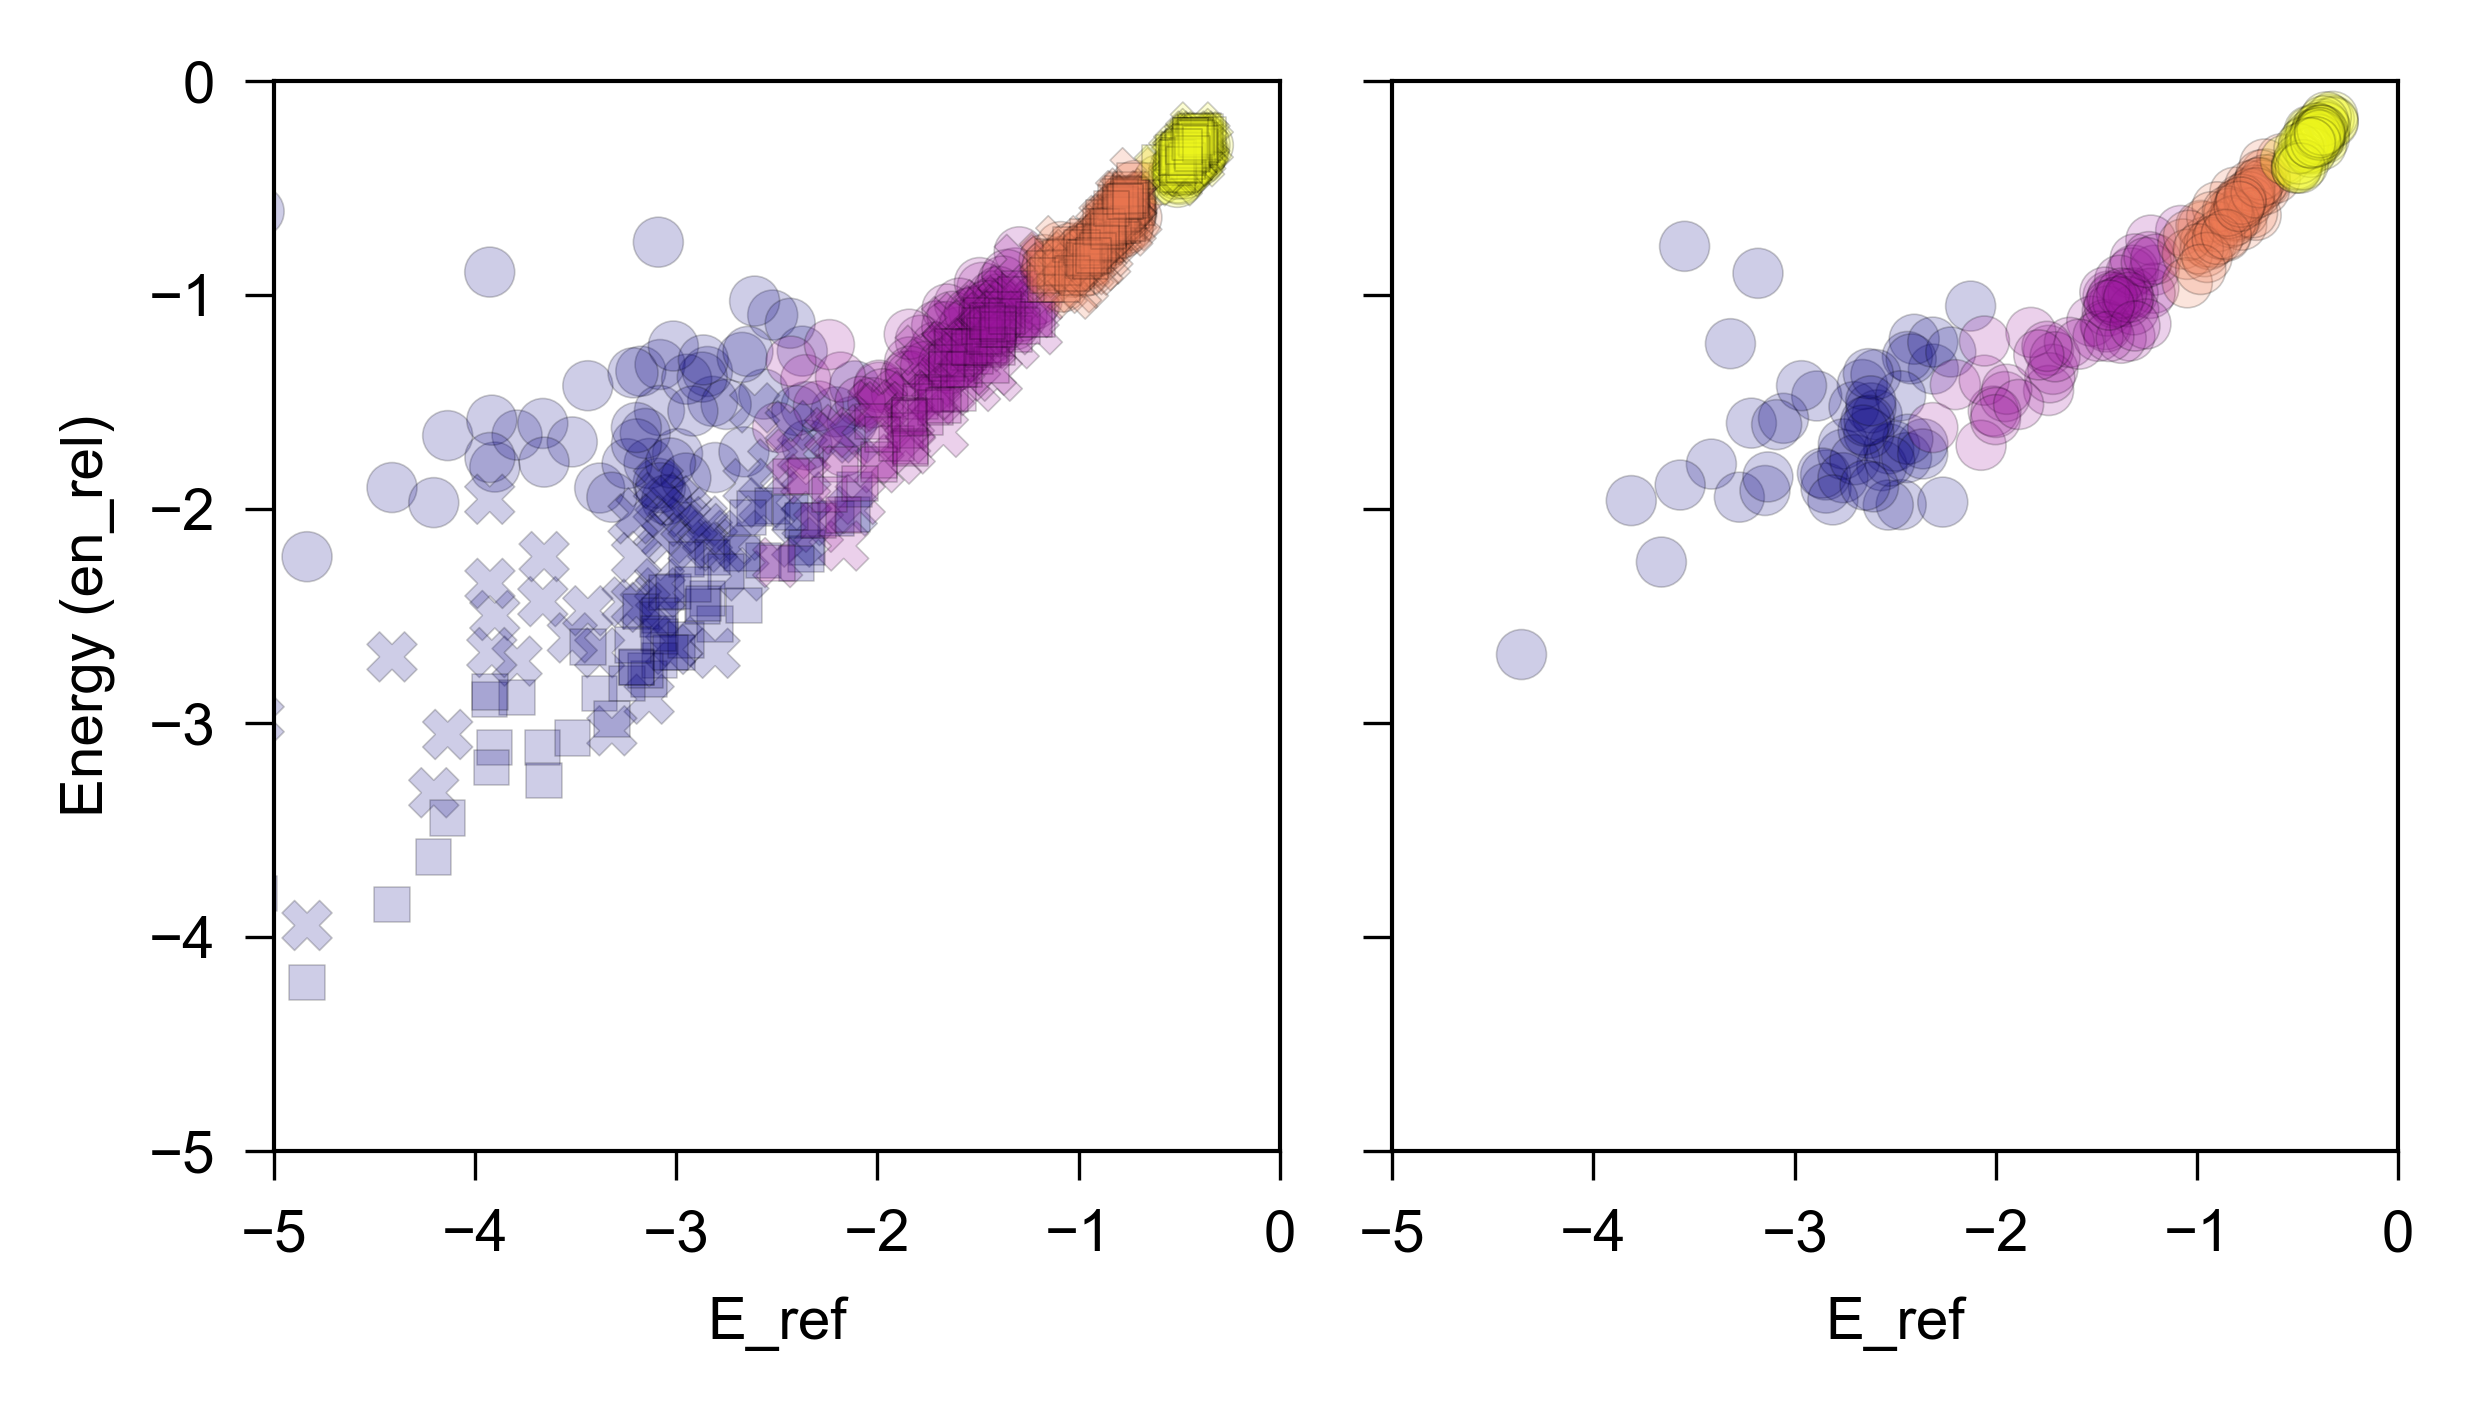

In [95]:
fig_w, fig_h = 105 / 25.4, 60 / 25.4
fig, axs = plt.subplots(1, 2, figsize=(fig_w, fig_h), dpi=600, sharey=True,sharex=True)


ax = axs[0]
pdf = df_long[~df_long.probe.str.contains('O') & (df_long.touch_sphere_size > 1.5)]
sns.scatterplot(data=pdf, x='en_ref_C', y='en', hue='touch_sphere_size', style='probe', ax=ax, alpha=0.2, palette='plasma',
                edgecolor='black',linewidth=0.2,legend=False,
                )

ax = axs[1]
pdf = df_long[df_long.probe.str.contains('O')  & (df_long.touch_sphere_size > 1.5)]
sns.scatterplot(
    data=pdf, x='en_ref_O', y='en', hue='touch_sphere_size',  ax=ax, palette='plasma',
    legend=False, alpha=0.2, edgecolor='black',linewidth=0.2,
    style='probe'
    )


for ax in axs:
    ax.set_xlim(-5, 0)
    ax.set_ylim(-5, 0)
    ax.tick_params(width=0.4)
    ax.set_facecolor('white')
    ax.set_xlabel("E_ref", fontsize=7)
    ax.set_ylabel("Energy (en_rel)", fontsize=7)

    # Thin axes spines
    for spine in ax.spines.values():
        spine.set_linewidth(0.5)

fig.set_layout_engine(layout='tight')
# leg = axs[0].legend()  # get the legend object
# leg.get_frame().set_alpha(1)     # ← set solid background color

<Axes: xlabel='en_ref_C', ylabel='en'>

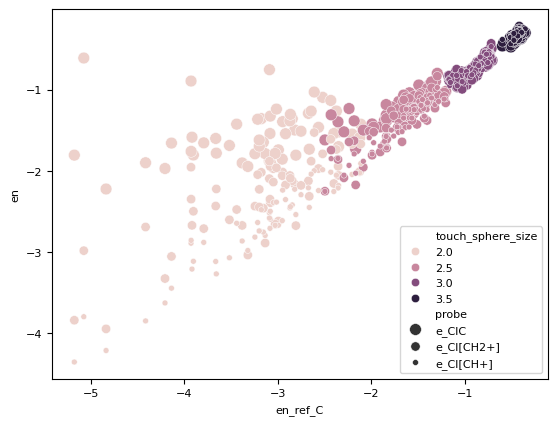

<Axes: xlabel='en_ref_O', ylabel='en'>

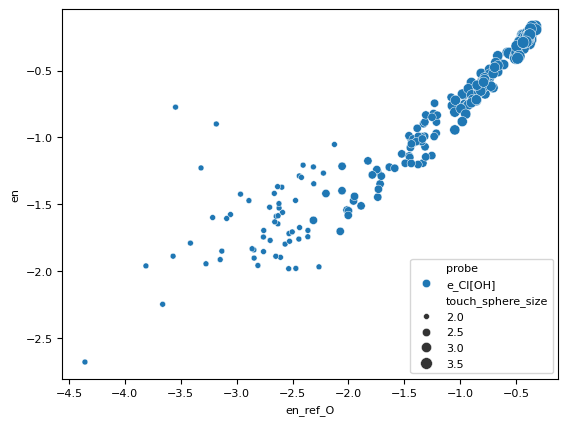

In [48]:
pdf = df_long[df_long.probe.str.contains('O')  & (df_long.touch_sphere_size > 1.5)]
sns.scatterplot(data=pdf, x='en_ref_O', y='en', hue='probe', size='touch_sphere_size')

## plot spectral

In [ ]:
relaxed_trj = read('/home/ef/liac22_home/git/CFT/examples/HEA_toy/gly_spectral/out_traj.xyz', index=':')

data = pd.DataFrame([a.info for a in relaxed_trj])
e_ref = data[data.d > (data.d.max() - 0.01)].en.max()
data['en_rel'] = data['en'] - e_ref


In [ ]:

# --- Adjustable Parameters ---
figsize = (3, 4)  # width, height in inches
fontsize = 7       # font size for labels and ticks
rows_per_bar = 10    # height of each KDE stripe
gap = 5              # vertical space between stripes
E_bins = 500         # Number of points in the energy grid

# --- Explicitly Set Constant Kernel Standard Deviation (Sigma) ---
constant_kernel_sigma = 0.02 # This is the "sigma" you want for each kernel

# --- Data Preparation ---
d_unique = np.sort(data['d'].unique())

# --- Energy range ---
E_min = -1.2
E_max = 0.2
E_grid = np.linspace(E_min, E_max, E_bins)

# --- Manual Gaussian KDE Function ---
def manual_gaussian_kde(data_points, evaluation_grid, kernel_sigma):
    """
    Performs a 1D Gaussian Kernel Density Estimation manually.
    """
    if len(data_points) == 0:
        return np.zeros_like(evaluation_grid)

    density = np.zeros_like(evaluation_grid, dtype=float)
    
    # Calculate pre-factors for the Gaussian function
    # Gaussian PDF: (1 / (sigma * sqrt(2 * pi))) * exp(-0.5 * ((x - mu) / sigma)^2)
    # We sum densities, so the (1/N) normalization usually applied after summation.
    # We normalize each row to max 1 later, so the constant pre-factor (1 / (sigma * sqrt(2 * pi)))
    # can be applied once after summation or effectively skipped if we normalize to max 1 anyway.
    # For now, let's keep it simple and sum un-normalized Gaussians, then normalize the total.

    for x_i in data_points:
        # Add a Gaussian centered at x_i to the density
        # The (x - mu)^2 part
        exponent = -0.5 * ((evaluation_grid - x_i) / kernel_sigma)**2
        # np.exp(exponent) is the un-normalized Gaussian shape
        density += np.exp(exponent)
    
    # Optional: Initial normalization by number of points to get actual density values
    # if len(data_points) > 0:
    #    density /= len(data_points)
    # The (1 / (sigma * sqrt(2 * pi))) factor could also be applied here
    # density /= (kernel_sigma * np.sqrt(2 * np.pi)) * len(data_points)

    return density

# --- Heatmap initialization ---
heatmap_height = len(d_unique) * (rows_per_bar + gap) - gap
heatmap = np.ones((heatmap_height, E_bins)) * np.nan

# --- Build KDE for each distance and populate heatmap ---
for i, di in enumerate(d_unique):
    Ei_values = data.loc[data['d'] == di, 'en_rel'].to_numpy()

    # Perform manual KDE
    density = manual_gaussian_kde(Ei_values, E_grid, constant_kernel_sigma)
    
    # Handle cases where density might be all zeros (e.g., no data points, or points outside grid)
    if np.max(density) > 0:
        density /= np.max(density)  # Normalize density to [0, 1] per row
    else:
        # If max density is 0, it means no meaningful KDE, so set to zeros
        density = np.zeros_like(E_grid)

    row_start = i * (rows_per_bar + gap)
    row_end = row_start + rows_per_bar
    if row_end > heatmap_height:
        row_end = heatmap_height
    heatmap[row_start:row_end, :] = np.tile(density, (row_end - row_start, 1))

# --- Plotting ---
fig, ax = plt.subplots(figsize=figsize, dpi=300)

sns.heatmap(
    heatmap,
    ax=ax,
    cmap='plasma',
    cbar=True,
    linewidths=0,
    linecolor='none',
    mask=np.isnan(heatmap)
)

# --- Add Black Box Outlines ---
for i in range(len(d_unique)):
    y0 = i * (rows_per_bar + gap)
    rect = Rectangle(
        (0, y0),
        E_bins,
        rows_per_bar,
        linewidth=0.8,
        edgecolor='black',
        facecolor='none'
    )
    ax.add_patch(rect)

# --- Flip Y axis (lowest d at bottom) ---
ax.invert_yaxis()

# --- Set Energy (X) Ticks ---
tick_step_x = 0.5
E_ticks = np.arange(E_min, E_max + tick_step_x/2, tick_step_x)
x_tick_idx = [np.argmin(np.abs(E_grid - t)) for t in E_ticks]
ax.set_xticks(x_tick_idx)
ax.set_xticklabels([f"{x:.1f}" for x in E_ticks], fontsize=fontsize)
ax.set_xlabel("Energy (en_rel)", fontsize=fontsize)

# --- Set Distance (Y) Ticks ---
y_tick_idx = [i * (rows_per_bar + gap) + rows_per_bar / 2 for i in range(len(d_unique))]
ax.set_yticks(y_tick_idx)
ax.set_yticklabels([f"{val:.2f}" for val in d_unique], fontsize=fontsize)
ax.set_ylabel("Distance (d)", fontsize=fontsize)

# --- Title ---
ax.set_title(f"KDE Heatmap of Energy per Distance (Manual Kernel Sigma: {constant_kernel_sigma})", fontsize=fontsize, pad=10)

# --- Adjust Colorbar ---
cbar = ax.collections[0].colorbar
cbar.ax.tick_params(labelsize=fontsize)
cbar.set_label('Normalized Density', fontsize=fontsize)

plt.tight_layout()
plt.show()

In [ ]:
# Fragment?

In [ ]:
data1 = pd.read_csv('/home/ef/liac22_home/git/CFT/examples/HEA_toy/N2H_anisotropic/data_4147.csv')
data2 = pd.read_csv('/home/ef/liac22_home/git/CFT/examples/HEA_toy/N2H_anisotropic/data_3469.csv')

for data in [data1,data2]:
    data['en_rel'] = data['en']-data.en.values[-1]

In [ ]:
atoms1 = read('/home/ef/liac22_home/git/CFT/examples/HEA_toy/N2H_anisotropic/out_traj_4147.xyz', index=1500)
atoms2 = read('/home/ef/liac22_home/git/CFT/examples/HEA_toy/N2H_anisotropic/out_traj_3469.xyz', index=1500)

In [ ]:
write('/mnt/c/Users/ef/Desktop/tmp/top_1500.xyz', atoms2)
write('/mnt/c/Users/ef/Desktop/tmp/bridge_1500.xyz', atoms1)

In [ ]:
sns.histplot(data1.en_rel.values)

In [ ]:
# import matplotlib.pyplot as plt
# import numpy as np

# # --- Data ---
# # data = data[data.d > -.1]
# r_vals = data["r"].to_numpy()
# d_vals = data["d"].to_numpy()
# en_vals = data["en_rel"].to_numpy()

# # --- Plot setup ---
# fig, ax = plt.subplots(figsize=(8, 5))
# angle_in_degrees = True  # Change to False if already radians

# if angle_in_degrees:
#     r_vals = np.deg2rad(r_vals)  # optional, keep consistent if polar coordinates used

# # --- Plot one line per distance ---
# for di in np.sort(data["d"].unique()):
#     mask = data["d"] == di
#     r_i = r_vals[mask]
#     en_i = en_vals[mask]

#     # Sort by r for smooth line
#     idx = np.argsort(r_i)
#     r_i = r_i[idx]
#     en_i = en_i[idx]

#     ax.plot(
#         r_i,
#         en_i,
#         label=f"d = {di:.2f}",
#         linewidth=1.2,
#         alpha=0.9
#     )

# # --- Labels & formatting ---
# ax.set_xlabel("Angle (radians)" if not angle_in_degrees else "Angle (r, degrees)", fontsize=10)
# ax.set_ylabel("Energy (en_rel)", fontsize=10)
# ax.set_title("Energy vs Angle for Each Distance (d)", fontsize=11)
# ax.legend(title="Distance (d)", fontsize=8)
# ax.grid(True, linestyle="--", alpha=0.4)

# plt.tight_layout()
# plt.show()


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import griddata

# --- Parameters ---
figsize_mm = (36, 16)  # width, height in millimeters
figsize_inch = (figsize_mm[0] / 25.4, figsize_mm[1] / 25.4)
vmin, vmax = -1, 0
cmap = "plasma"
angle_in_degrees = True  # False if already radians
highlight_index = 1500   # index of data point to mark

def make_polar(ax, df):
    r_vals = df["r"].to_numpy()
    d_vals = df["d"].to_numpy()
    en_vals = df["en_rel"].to_numpy()

    if angle_in_degrees:
        r_vals = np.deg2rad(r_vals)

    # --- Grid ---
    r_bins, d_bins = 300, 300
    r_grid = np.linspace(r_vals.min(), r_vals.max(), r_bins)
    d_grid = np.linspace(d_vals.min(), d_vals.max(), d_bins)
    R, D = np.meshgrid(r_grid, d_grid)

    # --- Interpolate energy onto grid ---
    Z = griddata((r_vals, d_vals), en_vals, (R, D), method="linear", fill_value=np.nan)

    # --- Plot heatmap ---
    ax.pcolormesh(R, D, Z, cmap=cmap, shading="auto", vmin=vmin, vmax=vmax)

    # --- Mark specific data point ---
    if highlight_index < len(df):
        r_pt = r_vals[highlight_index]
        d_pt = d_vals[highlight_index]
        ax.plot(r_pt, d_pt, "x", color="white", markersize=2, mew=0.8)

    # --- Minimal style ---
    ax.set_theta_zero_location("N")
    ax.set_theta_direction(-1)
    ax.set_rlabel_position(90)
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_xticklabels([])
    ax.set_yticklabels([])
    ax.grid(False)
    ax.set_frame_on(False)


# --- Subplots ---
fig, axes = plt.subplots(1, 2, figsize=figsize_inch, subplot_kw=dict(projection="polar"), dpi=600)

make_polar(axes[0], data1)
make_polar(axes[1], data2)

plt.subplots_adjust(wspace=0.02, hspace=0)
plt.show()


In [ ]:
from glob import glob
import numpy as np
from ase.visualize import view

In [ ]:
files = glob('../examples/Cu_smash/*_*/relaxed_*.xyz')
files.sort()

ref_en_dict = {}

for file in files:

    key = file.split('/relaxed_')[-1].split('.xyz')[0]
    # print(f'{key = }')

    atoms = read(file)
    # en = atoms.info['static_energy']#
    en = atoms.get_potential_energy()
    
    ref_en_dict['grd_'+key] = en

ref_en_dict

In [ ]:
grid_atoms = read('/home/ef/Code/CFT/examples/Cu_smash/0_5/grd_top0.xyz')
grid_atoms.arrays['e_H_0']

In [ ]:
view(atoms)

In [ ]:
view(read('/home/ef/Code/CFT/examples/Cu_smash/naked_particle.xyz'))

In [ ]:
en_naked = read('/home/ef/Code/CFT/examples/Cu_smash/naked_particle.xyz').get_potential_energy()

files = glob('../examples/Cu_smash/*_*/grd*')
files.sort()

data = {}

for file in files:

    key = file.split('/')[-1].split('.xyz')[0]
    # print(f'{key = }')
    data[key] = read(file)

for name, grid_atoms in data.items():
    if 'naked' in name:
        continue
    
    naked_atoms = data[name+'_naked']

    keys = [k for k in grid_atoms.arrays.keys()]
    for k in keys:
        if 'e_' in k and 'grad' not in k:
            
            mask = (grid_atoms.arrays[k] - np.min(grid_atoms.arrays[k])) < 2
            grid_atoms.arrays['delta_'+k] = grid_atoms.arrays[k]- ref_en_dict[name] - naked_atoms.arrays[k] + en_naked
            
            grid_atoms.arrays['ref_'+k] = naked_atoms.arrays[k] - en_naked
            eref = np.min(grid_atoms.arrays['ref_' + k])
            grid_atoms.arrays['ref_'+k] -= eref
            grid_atoms.arrays['rel_'+k] = grid_atoms.arrays[k] - ref_en_dict[name]
            grid_atoms.arrays['rel_'+k] -= eref
            

            # grid_atoms.arrays['delta_'+k] -= np.min(grid_atoms.arrays['delta_'+k])
            # grid_atoms.arrays['delta_'+k] *= mask
            # grid_atoms.arrays['delta_'+k] += ~mask*2
        if 'grad' in k:
            _ = grid_atoms.arrays.pop(k)
        # grid_atoms.arrays['rel_'+k] = grid_atoms.arrays[k] - np.min(grid_atoms.arrays[k])


trj = [grid_atoms for name, grid_atoms in data.items() if 'naked' not in name]


In [ ]:
write('/mnt/c/Users/ef/Desktop/tmp/x.xyz', trj)

## make data for Kjell

In [ ]:
rh_trj = read('/home/ef/Code/bo-adsorbate/examples/run_particle/rh_28.xyz', index=':')
len(rh_trj)

In [ ]:
# for atoms in rh_trj:
#     print(atoms.get_chemical_formula())

In [ ]:
# relaxed_trj = read('/home/ef/kuma_scratch/rh28_lignads/relaxed_out.xyz', index=':')

relaxed_trj = read('/home/ef/Code/CFT/examples/rh28_lignads/relaxed_out.xyz', index=':')

len(relaxed_trj)

In [ ]:
# for atoms in relaxed_trj:
#     print(atoms.get_chemical_formula())

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from dscribe.descriptors import SOAP
from sklearn.manifold import TSNE
from sklearn.preprocessing import StandardScaler


def gather_species(atoms_list):
    species = set()
    for at in atoms_list:
        species.update(at.get_chemical_symbols())
    return sorted(list(species))


def compute_rh_centered_soap(atoms_list, soap_params, species):
    soap = SOAP(species=species, **soap_params)
    soap_vectors = []
    rh_counts = []
    for at in atoms_list:
        symbols = at.get_chemical_symbols()
        rh_indices = [i for i, s in enumerate(symbols) if s == "Rh"]
        if len(rh_indices) == 0:
            soap_vectors.append(np.full(soap.get_number_of_features(), np.nan))
            rh_counts.append(0)
            continue
        desc = soap.create(at, centers=rh_indices)  # centers = indices
        avg = np.mean(desc, axis=0)
        soap_vectors.append(avg)
        rh_counts.append(len(rh_indices))
    return np.vstack(soap_vectors), np.array(rh_counts)


def make_rh_soap_tsne_df(atoms_list):
    species = gather_species(atoms_list)
    print("Species for SOAP:", species)

    soap_vecs, rh_counts = compute_rh_centered_soap(atoms_list, soap_params, species)
    mask = ~np.isnan(soap_vecs).any(axis=1)
    soap_valid = soap_vecs[mask]
    atoms_valid = [at for i, at in enumerate(atoms_list) if mask[i]]

    # scale and embed
    soap_scaled = StandardScaler().fit_transform(soap_valid)
    tsne = TSNE(**TSNE_PARAMS)
    coords = tsne.fit_transform(soap_scaled)

    # potential energies
    energies = [at.get_potential_energy() for at in atoms_valid]
    e_per_ligand = [
        (at.get_potential_energy() - at.info['static_energy'])/at.info['n_fragments'] for at in atoms_valid
        ]
    n_fragments = [at.info['n_fragments'] for at in atoms_valid]

    df = pd.DataFrame({
        "tsne_x": coords[:, 0],
        "tsne_y": coords[:, 1],
        "energy": energies,
        'relative energy': e_per_ligand,
        'n_fragments': n_fragments
    })

    return df, soap_vecs


def plot_tsne_energy(df):
    plt.figure(figsize=(6, 5))
    sc = plt.scatter(df.tsne_x, df.tsne_y, c=df['relative energy'], cmap="plasma", s=40)
    plt.colorbar(sc, label="Relative energy (eV)")
    # plt.title("t-SNE of Rh-centered SOAP vectors (colored by energy)")
    plt.xlabel("t-SNE 1")
    plt.ylabel("t-SNE 2")
    plt.tight_layout()
    plt.show()


import numpy as np
import matplotlib.pyplot as plt
from ase.visualize.plot import plot_atoms
import random


def plot_tsne_with_structures(df, atoms_list, n_rows=3, n_cols_each_side=3, fig_size=(14, 8)):
    """
    df: DataFrame with 'tsne_x', 'tsne_y', 'energy'
    atoms_list: full dataset (ASE Atoms objects), in the same order used to build df
    """

    n_total = n_rows * n_cols_each_side * 2  # left + right
    chosen_idx = random.sample(list(df.index), min(n_total, len(df)))

    left_idx = chosen_idx[: n_rows * n_cols_each_side]
    right_idx = chosen_idx[n_rows * n_cols_each_side :]

    # fixed drawing parameters for consistent scale
    common_kw = {"radii": 1.3, "rotation": ("45x,45y,0z"), "show_unit_cell": 0}

    # figure grid
    fig = plt.figure(figsize=fig_size, dpi=600)
    gs = fig.add_gridspec(n_rows, 2 * n_cols_each_side + 1, wspace=0.05, hspace=0.05)

    # left structures
    for i in range(n_rows):
        for j in range(n_cols_each_side):
            idx = i * n_cols_each_side + j
            if idx >= len(left_idx): continue
            at_idx = left_idx[idx]
            ax = fig.add_subplot(gs[i, j])
            plot_atoms(atoms_list[at_idx], ax, **common_kw)
            ax.axis("off")

    # center TSNE
    ax_center = fig.add_subplot(gs[:, n_cols_each_side : -n_cols_each_side])
    sc = ax_center.scatter(df.tsne_x, df.tsne_y, c=df['n_fragments'], cmap="plasma", s=40, alpha=0.8)
    # highlight shown structures
    highlight_idx = left_idx + right_idx
    ax_center.scatter(df.tsne_x.iloc[highlight_idx],
                      df.tsne_y.iloc[highlight_idx],
                      facecolors='none', edgecolors='black', s=120, linewidths=1.5, label="Shown structures")
    ax_center.set_xlabel("t-SNE 1")
    ax_center.set_ylabel("t-SNE 2")
    ax_center.set_title("t-SNE embedding")
    plt.colorbar(sc, ax=ax_center, fraction=0.046, pad=0.04, label="Energy (eV)")
    ax_center.legend(loc="best")

    # right structures
    for i in range(n_rows):
        for j in range(n_cols_each_side):
            idx = i * n_cols_each_side + j
            if idx >= len(right_idx): continue
            at_idx = right_idx[idx]
            ax = fig.add_subplot(gs[i, -(n_cols_each_side) + j])
            plot_atoms(atoms_list[at_idx], ax, **common_kw)
            ax.axis("off")

    plt.show()


In [ ]:
# === Parameters ===
soap_params = {
    "r_cut": 5.0,
    "n_max": 8,
    "l_max": 6,
    "sigma": 0.5,
    "periodic": False,
    "sparse": False,
}
TSNE_PARAMS = {"n_components": 2, "perplexity": 4, "learning_rate": 200, "random_state": 42}


# df, soap_vectors = rh_soap_tsne(relaxed_trj)
df, soap_vectors = make_rh_soap_tsne_df(relaxed_trj)

In [ ]:
# plot_tsne_energy(df)
plot_tsne_with_structures(df, relaxed_trj, n_rows=3, n_cols_each_side=1, fig_size=(14, 4))

In [ ]:
view(relaxed_trj)

In [ ]:
from cft import Manifold
m = Manifold(rh_trj[0], mode='particle', precision=2.)

In [ ]:
m.view_hedgehog()

In [ ]:
from glob import glob

In [ ]:
files = glob('/home/ef/kuma_scratch/cft_Cu_smash/smash_hard/*cov0*xyz')
files.sort()


trj = [read(file, index=-1) for file in files]


In [ ]:
view(trj)

In [ ]:
f2.positions+=[0,0,5]